Hexadic Diamond via SageMath Coxeter / Root System Machinery
=============================================================

### Erv Wilson's Hexadic Diamond is derivable from the A4 root system, 

Key is a mapping of Coxeter-theoretic objects to Just Intonation ratios:
  - the 10 weights of the standard representation (±e_i) providing the otonal/utonal intervals;
  - the 20 roots of A4 (ratios rI[i]/rI[j]), giving the combination (of otonal/utonal) product ratios;
  - and, the origin (unison).
The Hexadic Diamond follows from projection onto onto the 72-degree eigenplane of the Coxeter element.

The goal here is to draw from the Coxeter Theory the permutation matrix, roots (note ratios) and projection (eigenvector) and do so in a manner consistent with choices made in creating the Penrose Tiling.

In [1]:
import sys
sys.path.insert(0, '..')
from coxeter_a4 import build_a4_system, build_eigenspaces, eigenvec_to_proj, algebraic_constants

from sage.all import (
    CyclotomicField, WeylGroup,
    RootSystem, matrix, vector, QQ, AA, SR,
    cos, sin, pi, sqrt, I, n as numerical,
    Graphics, point2d, line2d, text as sage_text,
    Rational, Integer
)

import numpy as np
import matplotlib.pyplot as plt

#### Build the A4 root system

In [2]:
R, ambient, W, s, cox, P = build_a4_system()
C = R.cartan_matrix()

positive_roots = list(ambient.positive_roots())
all_roots = list(ambient.roots())

print("A4 Root System")
print(f"  Number of positive roots: {len(positive_roots)}")
print(f"  Total roots: {len(all_roots)}")
print(f"  Cartan matrix:\n{C}")

a = vector([1, 0, 0, 0])
b = vector([0, 1, 0, 0])
inner = a * C * b
print(f"<α₁, α₂> = {inner}")

v1 = vector([0, 1, -1, 0, 0])
v2 = vector([0, 0, 1, -1, 0])
print(f"Ambient dot product: {v1.dot_product(v2)}")

In [3]:
# Two roots that share an index have inner product ±1
a = vector([1, 0, 0, 0])  # α₁ = ε₁ − ε₂
b = vector([0, 1, 0, 0])  # α₂ = ε₂ − ε₃

inner = a * C * b
print(f"<α₁, α₂> = {inner}")  # -1

v1 = vector([0, 1, -1, 0, 0])
v2 = vector([0, 0, 1, -1, 0])
print(f"Ambient dot product: {v1.dot_product(v2)}")  # -1

<α₁, α₂> = -1
Ambient dot product: -1


In [4]:
simple_roots = list(ambient.simple_roots())
for i, r in enumerate(simple_roots):
    print(f"  α{i+1} = {r.to_vector()}")

  α1 = (1, -1, 0, 0, 0)
  α2 = (0, 1, -1, 0, 0)
  α3 = (0, 0, 1, -1, 0)
  α4 = (0, 0, 0, 1, -1)


#### Set up otonal and utonal ratios from basis vectors

+εᵢ and −εᵢ are the "single harmonic" and "single subharmonic" ratios

In [5]:
# The basis vectors ε₁ ... ε₅
eps = [ambient.basis()[i] for i in ambient.basis().keys()]

otonal = [e_.to_vector() for e_ in eps]       # five vectors like (1,0,0,0,0)
utonal = [(-e_).to_vector() for e_ in eps]    # five vectors like (-1,0,0,0,0)

#### Extract the roots and develop the permutation matrix

In [6]:
roots = [r.to_vector() for r in ambient.roots()]

print("Coxeter element matrix P:")
print(P)
R.dynkin_diagram()

Coxeter element matrix P:
[0 0 0 0 1]
[1 0 0 0 0]
[0 1 0 0 0]
[0 0 1 0 0]
[0 0 0 1 0]


O---O---O---O
1   2   3   4   
A4

#### Identify Eigenvector to be used for projection to 2D plane.
This will give the space $E_{//}$ , consistent with the Penrose tiling.

In [7]:
K, zeta, w_par, w_perp = build_eigenspaces(P)
w = w_par   # E∥ eigenvector (used downstream)

espaces = P.change_ring(K).eigenspaces_right()
print("Eigenspaces of the Coxeter element:")
for ev, V in espaces:
    print(f"  eigenvalue = {ev},  dimension = {V.dimension()}")
print(f"E∥ eigenvector (over Q(ζ₅)):")
print(f"  w = {w}")

Eigenspaces of the Coxeter element:
  eigenvalue = 1,  dimension = 1
  eigenvalue = zeta5,  dimension = 1
  eigenvalue = zeta5^2,  dimension = 1
  eigenvalue = zeta5^3,  dimension = 1
  eigenvalue = -zeta5^3 - zeta5^2 - zeta5 - 1,  dimension = 1
E∥ eigenvector (over Q(ζ₅)):
  w = (1, -zeta5^3 - zeta5^2 - zeta5 - 1, zeta5^3, zeta5^2, zeta5)


In [8]:
proj = eigenvec_to_proj(w, K)

# Keep embedding available for downstream verification cells
embedding = K.complex_embedding()

#### Verify that the basis corresponds to $E_{//}$ s.t. basis vectors are rotated by $\frac{2\pi}{5}$.

array([[ 0.63245553,  0.19543951, -0.51166727, -0.51166727,  0.19543951],
       [ 0.        , -0.60150096, -0.37174803,  0.37174803,  0.60150096]])

In [9]:
pi_unicode = "\u03C0"

e1 = proj @ np.array([0, 1, 0, 0, 0])
e2 = proj @ np.array([0, 0, 1, 0, 0])
e1 = e1 / np.linalg.norm(e1)
e2 = e2 / np.linalg.norm(e2)
p_rotation = np.arccos(np.dot(e1, e2)) * (5 / np.pi)
print(f'-->5D basis vectors are rotated in 2D plane by ({p_rotation}{pi_unicode})/5')

-->5D basis vectors are rotated in 2D plane by (2.0π)/5


In [10]:
proj

array([[ 0.63245553,  0.19543951, -0.51166727, -0.51166727,  0.19543951],
       [-0.        ,  0.60150096,  0.37174803, -0.37174803, -0.60150096]])

#### The roots of A4 are intevals between otonal and utonal elements

This bridge from Coxeter theory and the Hexadic Diamond is the assignment of odd harmonics to basis vectors. 

In [11]:
roots_5D = [(r_).to_vector() for r_ in all_roots]

hexadic_ratios = np.vstack((np.array((0,0,0,0,0)),np.array(otonal),np.array(utonal),np.array(roots_5D)))
# Every point in the diamond satisfies: at most 1 positive, at most 1 negative exponent.
# This holds by construction: origin has none, ±εᵢ have one, and roots eᵢ−eⱼ have exactly one of each.
assert all((np.sum(pt<0) < 2) and (np.sum(pt>0) < 2) for pt in hexadic_ratios)

xy_ = []
r_ = []      # raw sympy Rationals (no octave reduction)
pts5_ = []

rI = np.array([3,5,7,9,11])

for pt5 in hexadic_ratios:
    pS = Rational(rI[0],1)**Integer(pt5[0]) * \
         Rational(rI[1],1)**Integer(pt5[1]) * \
         Rational(rI[2],1)**Integer(pt5[2]) * \
         Rational(rI[3],1)**Integer(pt5[3]) * \
         Rational(rI[4],1)**Integer(pt5[4])

    r_.append(pS)
    xy_.append(proj@pt5)
    pts5_.append(pt5.copy())

xy_ = np.asarray(xy_)
pts5_ = np.asarray(pts5_)

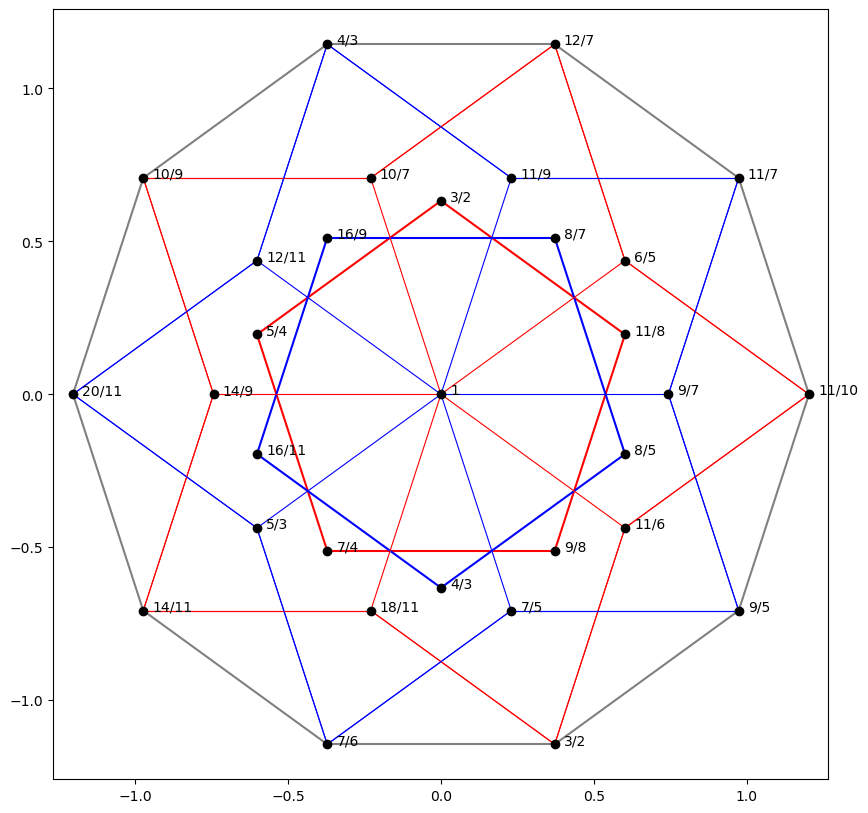

In [12]:
def draw_pentagon(ax, indices, color):
    angles = np.arctan2([y_[i] for i in indices], [x_[i] for i in indices])
    indices = [indices[k] for k in np.argsort(angles)]
    for k in range(len(indices)):
        i, j = indices[k], indices[(k+1) % len(indices)]
        ax.plot([x_[i], x_[j]], [y_[i], y_[j]], color=color, linewidth=1.5, zorder=0)
        
def find_idx(pt):
    matches = np.where(np.all(pts5_ == np.array(pt, dtype=float), axis=1))[0]
    return matches[0] if len(matches) else None
    
def cyclic(lst, i):
    return lst[-i:] + lst[:-i] if i > 0 else lst[:]

def draw_belt(ax, a, b, color, lw=0.8):
    """Draw V-shaped lines: outer[k] → bridge[k] → outer[k+1]
    a: base outer-belt point, b: base bridge point (cyclic permutations of each)"""
    outer_pts5 = [cyclic(a, i) for i in range(5)]
    inner_pts5 = [cyclic(b, i) for i in range(5)]
    for k in range(5):
        i1 = find_idx(outer_pts5[k])
        i2 = find_idx(outer_pts5[(k+1) % 5])
        im = find_idx(inner_pts5[k])
        if None not in (i1, i2, im):
            ax.plot([x_[i1], x_[im]], [y_[i1], y_[im]], color=color, linewidth=lw, zorder=0)
            ax.plot([x_[im], x_[i2]], [y_[im], y_[i2]], color=color, linewidth=lw, zorder=0)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)

# Rotate 90 degrees to align with Erv Wilson's Hexadic Diamond
x_ = -xy_[:,1]
y_ = xy_[:,0]

# Step 1: red pentagon — otonal basis points (single element == +1)
idx_otonal = [i for i, pt in enumerate(pts5_)
              if np.sum(pt != 0) == 1 and pt.max() == 1]
draw_pentagon(ax, idx_otonal, 'r')

# Step 2: blue pentagon — utonal basis points (single element == -1)
idx_utonal = [i for i, pt in enumerate(pts5_)
              if np.sum(pt != 0) == 1 and pt.min() == -1]
draw_pentagon(ax, idx_utonal, 'b')

# Step 3: blue (thin) lines — utonal star
draw_belt(ax, [-1, 0,  1, 0, 0],
              [ 0,-1,  1, 0, 0], 'b')

# Step 4: red (thin) lines — otonal star
draw_belt(ax, [ 1, 0, -1, 0, 0],
              [ 0, 1, -1, 0, 0], 'r')

# Step 5: grey decagon — connect the 10 outermost points
distances = np.sqrt(x_**2 + y_**2)
idx_outer10 = list(np.argsort(distances)[-10:])
angles = np.arctan2([y_[i] for i in idx_outer10], [x_[i] for i in idx_outer10])
idx_outer10 = [idx_outer10[k] for k in np.argsort(angles)]
for k in range(10):
    i, j = idx_outer10[k], idx_outer10[(k+1) % 10]
    ax.plot([x_[i], x_[j]], [y_[i], y_[j]], color='grey', linewidth=1.5, zorder=0)

# Step 6: radial lines from origin to bridge points, colored by star
# red_bridges = [cyclic([0,  1, -1, 0, 0], i) for i in range(5)]
# blue_bridges   = [cyclic([0, -1,  1, 0, 0], i) for i in range(5)]

# for pt in red_bridges:
#     i = find_idx(pt)
#     if i is not None:
#         ax.plot([0, x_[i]], [0, y_[i]], color='r', linewidth=0.8, zorder=0)

# for pt in blue_bridges:
#     i = find_idx(pt)
#     if i is not None:
#         ax.plot([0, x_[i]], [0, y_[i]], color='b', linewidth=0.8, zorder=0)

# The star lines follow Coxeter orbits: repeated application of P to a base root.
# P acts on εᵢ → εᵢ₊₁, so P·(εᵢ−εⱼ) = εᵢ₊₁−εⱼ₊₁.
#
# Each orbit is generated by applying P (as a matrix) to a starting root.

P_np = np.array(P)  # the 5x5 permutation matrix, already computed from ambient.weyl_group()

def coxeter_orbit(base, n=5):
    """Generate the orbit of a root under repeated application of the Coxeter element."""
    orbit = [np.array(base)]
    for _ in range(n - 1):
        orbit.append(P_np @ orbit[-1])
    return orbit

# Red star: base outer ε₀−ε₂, base bridge ε₁−ε₂
red_outer  = coxeter_orbit([1, 0, -1, 0, 0])
red_bridge = coxeter_orbit([0, 1, -1, 0, 0])

# Blue star: base outer ε₂−ε₀, base bridge ε₂−ε₁
blue_outer  = coxeter_orbit([-1, 0, 1, 0, 0])
blue_bridge = coxeter_orbit([0, -1, 1, 0, 0])

# V-shapes: outer[k] → bridge[k] → outer[k+1]
for k in range(5):
    i_o1 = find_idx(list(red_outer[k]))
    i_br = find_idx(list(red_bridge[k]))
    i_o2 = find_idx(list(red_outer[(k+1) % 5]))
    if None not in (i_o1, i_br, i_o2):
        ax.plot([x_[i_o1], x_[i_br]], [y_[i_o1], y_[i_br]], color='r', linewidth=0.8, zorder=0)
        ax.plot([x_[i_br], x_[i_o2]], [y_[i_br], y_[i_o2]], color='r', linewidth=0.8, zorder=0)

for k in range(5):
    i_o1 = find_idx(list(blue_outer[k]))
    i_br = find_idx(list(blue_bridge[k]))
    i_o2 = find_idx(list(blue_outer[(k+1) % 5]))
    if None not in (i_o1, i_br, i_o2):
        ax.plot([x_[i_o1], x_[i_br]], [y_[i_o1], y_[i_br]], color='b', linewidth=0.8, zorder=0)
        ax.plot([x_[i_br], x_[i_o2]], [y_[i_br], y_[i_o2]], color='b', linewidth=0.8, zorder=0)

# Radial lines from origin to bridge roots
for v in red_bridge:
    i = find_idx(list(v))
    if i is not None:
        ax.plot([0, x_[i]], [0, y_[i]], color='r', linewidth=0.8, zorder=0)

for v in blue_bridge:
    i = find_idx(list(v))
    if i is not None:
        ax.plot([0, x_[i]], [0, y_[i]], color='b', linewidth=0.8, zorder=0)
        
ax.plot(x_, y_, 'ko', zorder=1)
# Annotate with octave-reduced ratio
for i, pS in enumerate(r_):
    pS_oct = pS
    while pS_oct > 2: pS_oct /= 2
    while pS_oct < 1: pS_oct *= 2
    ax.annotate(str(pS_oct), xy=[x_[i]+0.03, y_[i]], textcoords='data')

plt.axis('equal')
plt.savefig('../hexadic_diamond_coxeter.png')
plt.show()

In [13]:
consts = algebraic_constants(K, zeta)
tau_exact = consts['tau_exact']

# Verify from root geometry: ratio of projected squared norms = τ²
norm_sq_adj = (1 - zeta) * (1 - zeta**4)    # |π(ε₁−ε₂)|²
norm_sq_non = (1 - zeta**2) * (1 - zeta**3)  # |π(ε₁−ε₃)|²
tau_sq_roots = norm_sq_non / norm_sq_adj

print(f"|π(ε₁−ε₂)|² = {norm_sq_adj}  =  {embedding(norm_sq_adj):.6f}")
print(f"|π(ε₁−ε₃)|² = {norm_sq_non}  =  {embedding(norm_sq_non):.6f}")
print(f"ratio        = {tau_sq_roots}  =  {embedding(tau_sq_roots):.6f}")
print(f"τ² (algebraic_constants) = {embedding(tau_exact**2):.6f}")
print(f"Match: {tau_sq_roots == tau_exact**2}")

|π(ε₁−ε₂)|² = zeta5^3 + zeta5^2 + 3  =  1.381966 + 0.000000*I
|π(ε₁−ε₃)|² = -zeta5^3 - zeta5^2 + 2  =  3.618034 - 0.000000*I
ratio        = -zeta5^3 - zeta5^2 + 1  =  2.618034 - 0.000000*I
τ² (algebraic_constants) = 2.618034 - 0.000000*I
Match: True
